# 📊 Phân tích & Visualize Chunks

Notebook này phân tích trực quan file `chunks.json` sinh ra từ script chunking PDF Luật bóng đá VFF.

## Mục tiêu

1. **Thống kê tổng quan** — số chunks, phân bố theo Luật/loại, character distribution
2. **Phát hiện outlier** — chunks quá dài / quá ngắn / có vấn đề
3. **Trực quan hóa** — biểu đồ phân bố giúp đánh giá chất lượng chunking
4. **Verify** — kiểm tra metadata có nhất quán không
5. **Explore** — duyệt chunks theo Luật/Mục

## 1. Setup

Cài đặt và import các thư viện cần thiết.

In [1]:
# Cài thư viện nếu chưa có (chạy 1 lần)
# !pip install pandas matplotlib seaborn plotly

import json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'  # hỗ trợ tiếng Việt

print('✅ Imports OK')

✅ Imports OK


## 2. Load Data

Đọc file `chunks.json` vào DataFrame để dễ phân tích.

In [2]:
# Đường dẫn file chunks - chỉnh lại nếu file ở chỗ khác
CHUNKS_PATH = 'data/processed/chunks.json'

# Fallback paths nếu file không ở đúng chỗ
for path in [CHUNKS_PATH, 'chunks.json', '../data/processed/chunks.json', '/mnt/user-data/outputs/chunks.json']:
    if Path(path).exists():
        CHUNKS_PATH = path
        break

print(f'📂 Đọc file: {CHUNKS_PATH}')

with open(CHUNKS_PATH, encoding='utf-8') as f:
    chunks = json.load(f)

df = pd.DataFrame(chunks)
print(f'✅ Loaded {len(df)} chunks')
print(f'\nCác cột: {list(df.columns)}')
df.head(3)

📂 Đọc file: ../data/processed/chunks.json
✅ Loaded 286 chunks

Các cột: ['chunk_id', 'text', 'section_type', 'luat_so', 'luat_ten', 'muc_so', 'muc_ten', 'dieu_khoan', 'special_section', 'source_page', 'char_count', 'breadcrumb', 'is_table']


,chunk_id,text,section_type,luat_so,luat_ten,muc_so,muc_ten,dieu_khoan,special_section,source_page,char_count,breadcrumb,is_table
0,PL_p1_part1,[PHỤ LỤC]\n\nQUYẾT ĐỊNH Về việc áp dụng Luật thi đấu Bóng đá 2021/2022 __________________ CHỦ TỊ...,phu_luc,NaN,NaN,NaN,NaN,NaN,NaN,1,958,PHỤ LỤC,False
1,PL_p1_part2,[PHỤ LỤC]\n\nLIÊN ĐOÀN BÓNG ĐÁ VIỆT NAM Số: 68 /QĐ-LĐBĐVN CỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM Độc...,phu_luc,NaN,NaN,NaN,NaN,NaN,NaN,1,868,PHỤ LỤC,False
2,Giới_thiệu_p7_part1,[Giới thiệu]\n\nTriết lý và tinh thần của Luật thi đấu Bóng đá là môn thể thao phổ biến nhất trê...,phu_luc,NaN,NaN,NaN,NaN,NaN,Giới thiệu,7,997,Giới thiệu,False


## 3. Tổng quan nhanh

Numbers quan trọng nhất cần biết ngay.

In [3]:
print('=' * 60)
print('📊 TỔNG QUAN NHANH')
print('=' * 60)
print(f'Tổng số chunks:           {len(df)}')
print(f'Số Luật khác nhau:        {df["luat_so"].nunique()}')
print(f'Số trang nguồn (PDF):     {df["source_page"].nunique()}')
print(f'Số loại section_type:     {df["section_type"].nunique()}')
print(f'Số chunks là bảng:        {df["is_table"].sum()}')
print()
print('📏 CHARACTER COUNT')
print(f'  Tổng ký tự:             {df["char_count"].sum():,}')
print(f'  Trung bình:             {df["char_count"].mean():.0f}')
print(f'  Trung vị (median):      {df["char_count"].median():.0f}')
print(f'  Std (độ lệch chuẩn):    {df["char_count"].std():.0f}')
print(f'  Min:                    {df["char_count"].min()}')
print(f'  Max:                    {df["char_count"].max()}')

📊 TỔNG QUAN NHANH
Tổng số chunks:           286
Số Luật khác nhau:        17
Số trang nguồn (PDF):     113
Số loại section_type:     4
Số chunks là bảng:        1

📏 CHARACTER COUNT
  Tổng ký tự:             147,856
  Trung bình:             517
  Trung vị (median):      408
  Std (độ lệch chuẩn):    345
  Min:                    97
  Max:                    1557


In [4]:
# Mô tả thống kê chi tiết hơn
df['char_count'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count     286.000000
mean      516.979021
std       344.737530
min        97.000000
10%       159.000000
25%       231.250000
50%       407.500000
75%       737.750000
90%      1020.000000
95%      1072.250000
99%      1495.300000
max      1557.000000
Name: char_count, dtype: float64

## 4. Phân bố Character Count

Đây là chỉ số **quan trọng nhất** để đánh giá chất lượng chunking. Nếu phân bố quá lệch, có chunks quá dài hoặc quá ngắn → cần xem lại logic chunking.

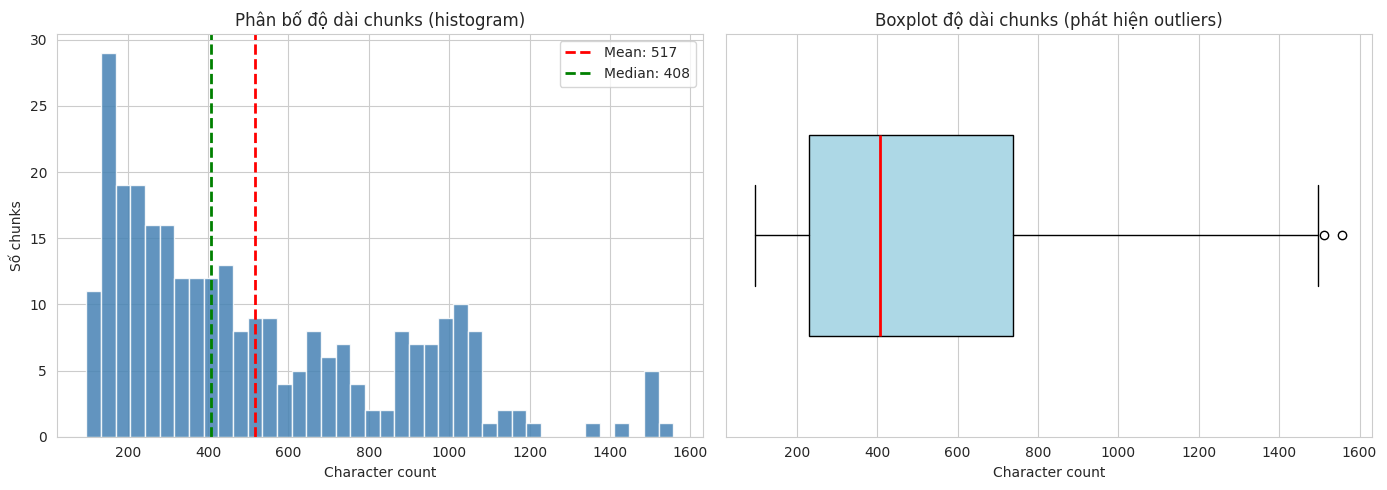

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['char_count'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['char_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["char_count"].mean():.0f}')
axes[0].axvline(df['char_count'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["char_count"].median():.0f}')
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Số chunks')
axes[0].set_title('Phân bố độ dài chunks (histogram)')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['char_count'], vert=False, widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_xlabel('Character count')
axes[1].set_title('Boxplot độ dài chunks (phát hiện outliers)')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

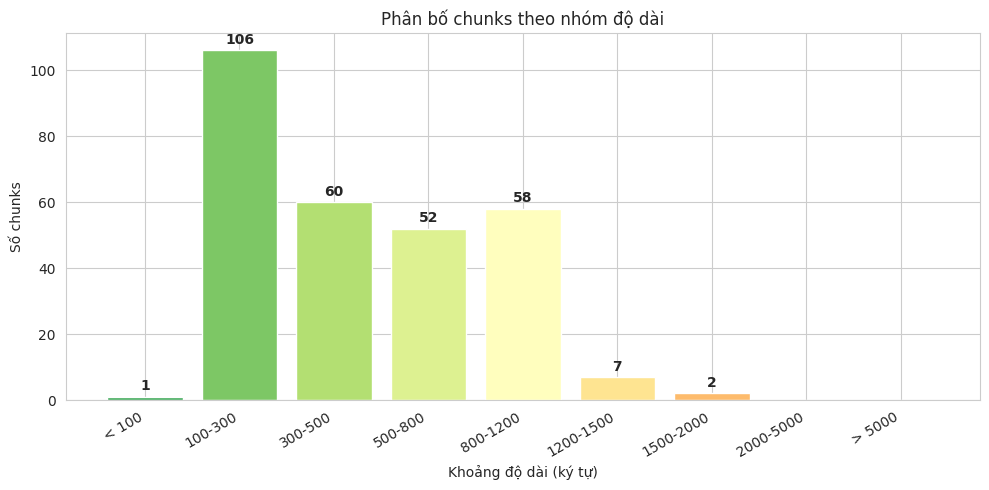


📋 Bảng chi tiết:


,Số chunks,Tỷ lệ %
size_bucket,,
< 100,1,0.3
100-300,106,37.1
300-500,60,21.0
500-800,52,18.2
800-1200,58,20.3
1200-1500,7,2.4
1500-2000,2,0.7
2000-5000,0,0.0
> 5000,0,0.0


In [6]:
# Phân nhóm theo size buckets - dễ thấy phân bố hơn histogram
bins = [0, 100, 300, 500, 800, 1200, 1500, 2000, 5000, float('inf')]
labels = ['< 100', '100-300', '300-500', '500-800', '800-1200', '1200-1500', '1500-2000', '2000-5000', '> 5000']
df['size_bucket'] = pd.cut(df['char_count'], bins=bins, labels=labels)

bucket_counts = df['size_bucket'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(bucket_counts)))
bars = ax.bar(range(len(bucket_counts)), bucket_counts.values, color=colors, edgecolor='white')
ax.set_xticks(range(len(bucket_counts)))
ax.set_xticklabels(bucket_counts.index, rotation=30, ha='right')
ax.set_xlabel('Khoảng độ dài (ký tự)')
ax.set_ylabel('Số chunks')
ax.set_title('Phân bố chunks theo nhóm độ dài')

# Thêm label trên đầu cột
for bar, val in zip(bars, bucket_counts.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📋 Bảng chi tiết:')
display(bucket_counts.to_frame('Số chunks').assign(
    **{'Tỷ lệ %': (bucket_counts / len(df) * 100).round(1)}
))

### 🚨 Phát hiện outliers

Chunks **quá ngắn** (< 100 ký tự) có thể là rác, không đủ context để embed.
Chunks **quá dài** (> 1500 ký tự) có thể vượt context window của embedding model nhỏ.

In [7]:
# Chunks quá ngắn
TOO_SHORT = 100
too_short = df[df['char_count'] < TOO_SHORT].sort_values('char_count')
print(f'⚠️  Chunks quá NGẮN (< {TOO_SHORT} ký tự): {len(too_short)}')
if len(too_short) > 0:
    display(too_short[['chunk_id', 'char_count', 'breadcrumb', 'text']].head(10))

⚠️  Chunks quá NGẮN (< 100 ký tự): 1


,chunk_id,char_count,breadcrumb,text
262,Trình_tự_VAR_M2_p143,97,Trình tự VAR > 2. Các tình huống nghiêm trọng/quyết định thay,[Trình tự VAR > 2. Các tình huống nghiêm trọng/quyết định thay]\n\nđổi trận đấu có thể được xem lại


In [8]:
# Chunks quá dài
TOO_LONG = 1500
too_long = df[df['char_count'] > TOO_LONG].sort_values('char_count', ascending=False)
print(f'⚠️  Chunks quá DÀI (> {TOO_LONG} ký tự): {len(too_long)}')
if len(too_long) > 0:
    display(too_long[['chunk_id', 'char_count', 'breadcrumb']].head(10))

⚠️  Chunks quá DÀI (> 1500 ký tự): 2


,chunk_id,char_count,breadcrumb
165,L11_M4_p95,1557,LUẬT 11 - VIỆT VỊ > 4. Những vi phạm và hình thức xử phạt
98,L04_M5_DK5.2,1512,"LUẬT 4 - TRANG THIẾT BỊ CỦA CẦU THỦ > 5. Khẩu hiệu, tuyên bố, hình ảnh và quảng cáo > 5.2"


In [9]:
# Chunk DÀI NHẤT - xem nội dung
longest = df.loc[df['char_count'].idxmax()]
print('🏆 CHUNK DÀI NHẤT')
print('=' * 60)
print(f'chunk_id:     {longest["chunk_id"]}')
print(f'char_count:   {longest["char_count"]}')
print(f'breadcrumb:   {longest["breadcrumb"]}')
print(f'source_page:  {longest["source_page"]}')
print(f'\n--- TEXT ---')
print(longest['text'][:1000] + ('\n...' if len(longest['text']) > 1000 else ''))

🏆 CHUNK DÀI NHẤT
chunk_id:     L11_M4_p95
char_count:   1557
breadcrumb:   LUẬT 11 - VIỆT VỊ > 4. Những vi phạm và hình thức xử phạt
source_page:  95

--- TEXT ---
[LUẬT 11 - VIỆT VỊ > 4. Những vi phạm và hình thức xử phạt]

- Nếu có lỗi việt vị, trọng tài cho đội đối phương hưởng quả phạt gián tiếp tại vị trí xảy ra lỗi, bao gồm cả khi lỗi xảy ra trên phần sân của cầu thủ phạm lỗi. - Một cầu thủ phòng ngự rời khỏi sân thi đấu mà không được sự cho phép của trọng tài sẽ bị coi là ở trên đường biên ngang hoặc biên dọc để xác định vị trí việt vị cho tới lần dừng trận đấu tiếp theo hoặc cho tới khi đội phòng ngự đưa bóng về phía đường giữa sân và ở ngoài khu vực phạt đền của đội phòng ngự. Nếu cầu thủ cố tình rời sân thi đấu, cầu thủ phải bị phạt thẻ vàng khi bóng ngoài cuộc ở tình huống tiếp theo. - Một cầu thủ tấn công có thể bước ra khỏi hoặc rời khỏi sân thi đấu để không tham gia vào trận đấu đang diễn ra. Nếu cầu thủ vào lại sân thi đấu từ đường biên ngang và tham gia vào trận đấu trư

In [10]:
# Chunk NGẮN NHẤT - xem nội dung
shortest = df.loc[df['char_count'].idxmin()]
print('🔻 CHUNK NGẮN NHẤT')
print('=' * 60)
print(f'chunk_id:     {shortest["chunk_id"]}')
print(f'char_count:   {shortest["char_count"]}')
print(f'breadcrumb:   {shortest["breadcrumb"]}')
print(f'source_page:  {shortest["source_page"]}')
print(f'\n--- TEXT ---')
print(shortest['text'])

🔻 CHUNK NGẮN NHẤT
chunk_id:     Trình_tự_VAR_M2_p143
char_count:   97
breadcrumb:   Trình tự VAR > 2. Các tình huống nghiêm trọng/quyết định thay
source_page:  143

--- TEXT ---
[Trình tự VAR > 2. Các tình huống nghiêm trọng/quyết định thay]

đổi trận đấu có thể được xem lại


## 5. Phân bố theo `section_type`

Xem mỗi loại chunk chiếm tỷ lệ bao nhiêu.

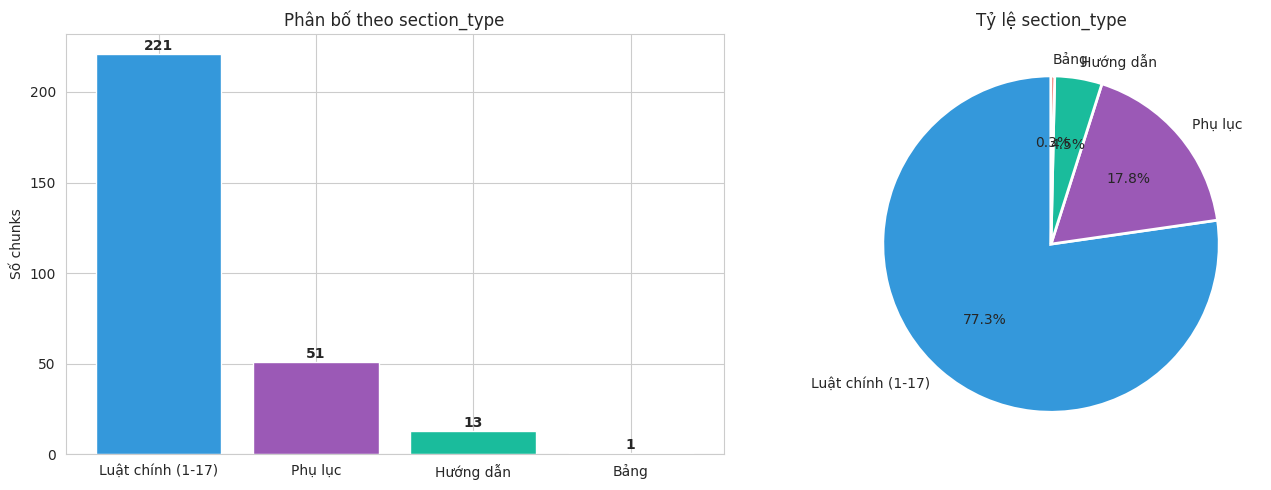

In [11]:
type_counts = df['section_type'].value_counts()
type_labels = {
    'luat': 'Luật chính (1-17)',
    'huong_dan': 'Hướng dẫn',
    'phu_luc': 'Phụ lục',
    'bang': 'Bảng'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_bar = ['#3498db', '#9b59b6', '#1abc9c', '#e74c3c']
axes[0].bar([type_labels.get(t, t) for t in type_counts.index], type_counts.values, color=colors_bar[:len(type_counts)])
axes[0].set_ylabel('Số chunks')
axes[0].set_title('Phân bố theo section_type')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(type_counts.values,
            labels=[type_labels.get(t, t) for t in type_counts.index],
            autopct='%1.1f%%',
            colors=colors_bar[:len(type_counts)],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Tỷ lệ section_type')

plt.tight_layout()
plt.show()

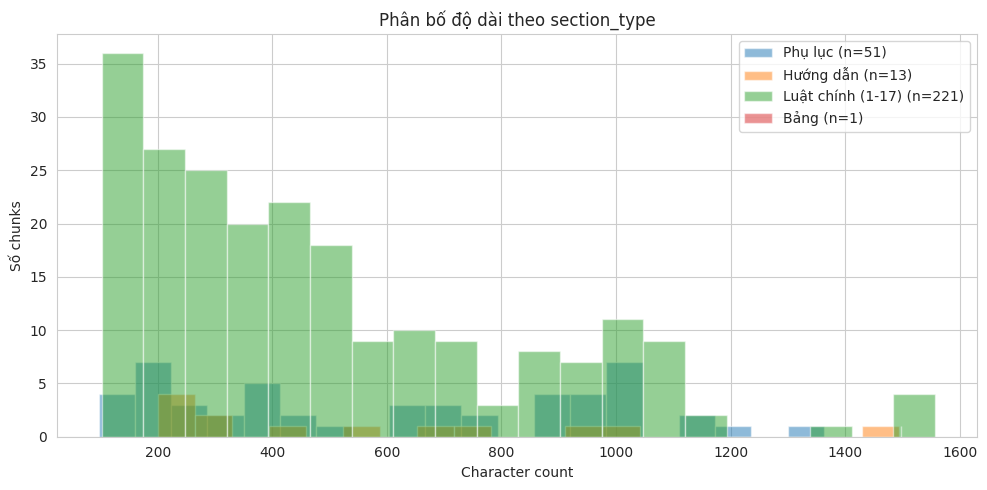

In [12]:
# Char count theo từng section_type
fig, ax = plt.subplots(figsize=(10, 5))

for stype in df['section_type'].unique():
    subset = df[df['section_type'] == stype]['char_count']
    ax.hist(subset, bins=20, alpha=0.5, label=f'{type_labels.get(stype, stype)} (n={len(subset)})')

ax.set_xlabel('Character count')
ax.set_ylabel('Số chunks')
ax.set_title('Phân bố độ dài theo section_type')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Phân bố theo Luật (1-17)

Mỗi Luật có bao nhiêu chunks, độ dài trung bình thế nào?

In [13]:
# Chỉ lấy chunks thuộc Luật 1-17 (luat_so không null)
df_law = df[df['luat_so'].notna()].copy()
df_law['luat_so'] = df_law['luat_so'].astype(int)

# Group by Luật
law_stats = df_law.groupby(['luat_so', 'luat_ten']).agg(
    num_chunks=('chunk_id', 'count'),
    total_chars=('char_count', 'sum'),
    avg_chars=('char_count', 'mean'),
    min_chars=('char_count', 'min'),
    max_chars=('char_count', 'max'),
    num_pages=('source_page', 'nunique'),
).reset_index().sort_values('luat_so')

law_stats['avg_chars'] = law_stats['avg_chars'].round(0).astype(int)
print(f'📋 Thống kê theo {len(law_stats)} Luật:')
law_stats

📋 Thống kê theo 17 Luật:


,luat_so,luat_ten,num_chunks,total_chars,avg_chars,min_chars,max_chars,num_pages
0,1,SÂN THI ĐẤU,21,10265,489,131,1495,10
1,2,BÓNG THI ĐẤU,10,2447,245,154,395,2
2,3,CẦU THỦ,27,10017,371,144,894,10
3,4,TRANG THIẾT BỊ CỦA CẦU THỦ,18,8774,487,116,1512,7
4,5,TRỌNG TÀI,18,10885,605,109,1494,9
5,6,CÁC QUAN CHỨC TRẬN ĐẤU KHÁC,12,5265,439,137,913,5
6,7,THỜI GIAN TRẬN ĐẤU,7,2100,300,159,718,2
7,8,BẮT ĐẦU VÀ BẮT ĐẦU LẠI TRẬN ĐẤU,6,3434,572,446,648,3
8,9,BÓNG TRONG CUỘC VÀ NGOÀI CUỘC,2,728,364,236,492,1
9,10,QUYẾT ĐỊNH KẾT QUẢ CỦA TRẬN ĐẤU,9,6298,700,212,1411,6


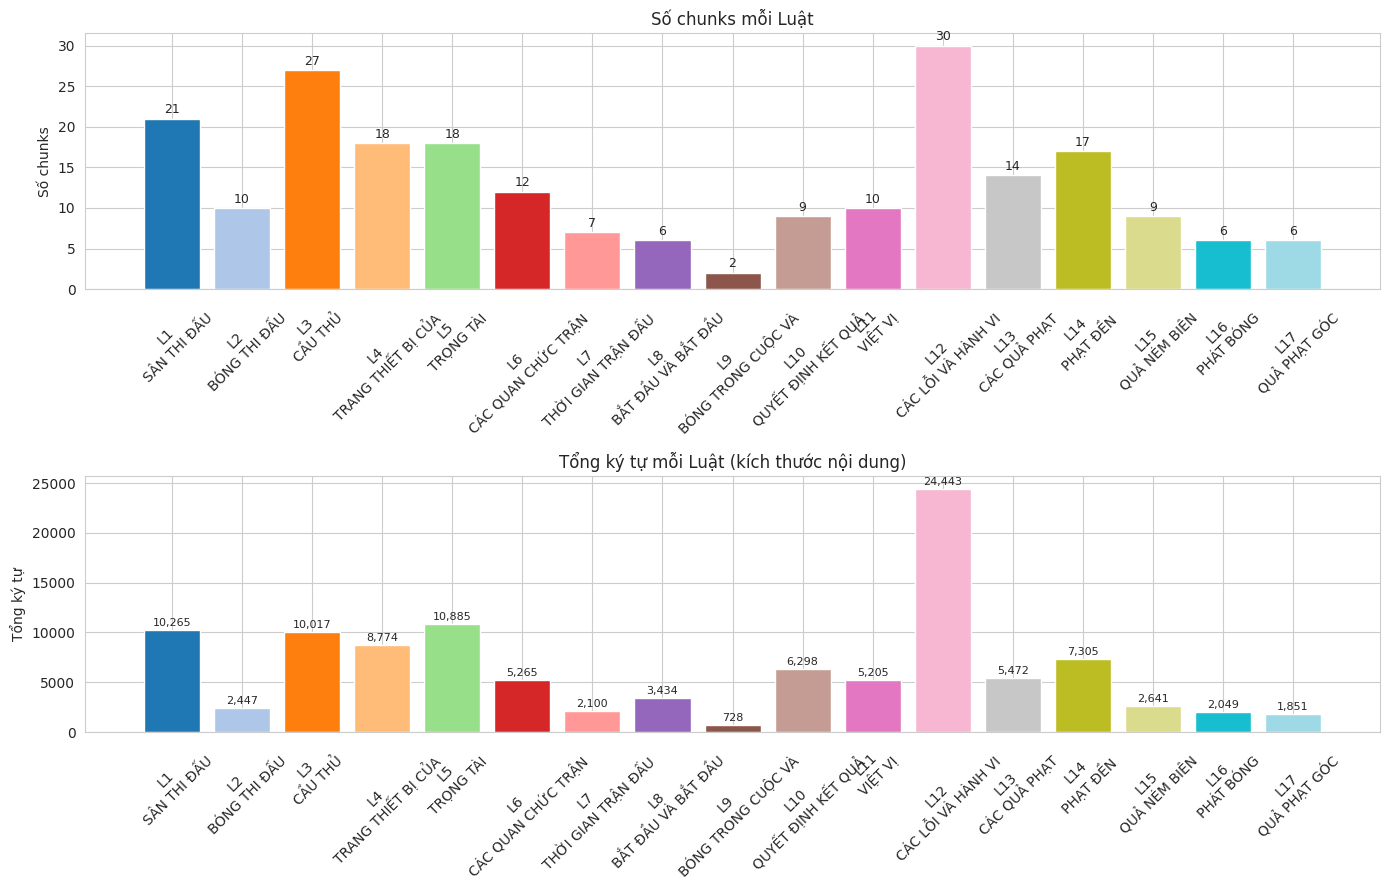

In [14]:
# Biểu đồ số chunks mỗi Luật
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Số chunks
x_labels = [f'L{int(row.luat_so)}\n{row.luat_ten[:18]}' for row in law_stats.itertuples()]
colors_law = plt.cm.tab20(np.linspace(0, 1, len(law_stats)))

bars1 = axes[0].bar(x_labels, law_stats['num_chunks'], color=colors_law, edgecolor='white')
axes[0].set_ylabel('Số chunks')
axes[0].set_title('Số chunks mỗi Luật')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, law_stats['num_chunks']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=9)

# Tổng ký tự
bars2 = axes[1].bar(x_labels, law_stats['total_chars'], color=colors_law, edgecolor='white')
axes[1].set_ylabel('Tổng ký tự')
axes[1].set_title('Tổng ký tự mỗi Luật (kích thước nội dung)')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, law_stats['total_chars']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/j7/x8f9tr_10hncrvyrrj0mt09c0000gn/T/ipykernel_11873/1506529827.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


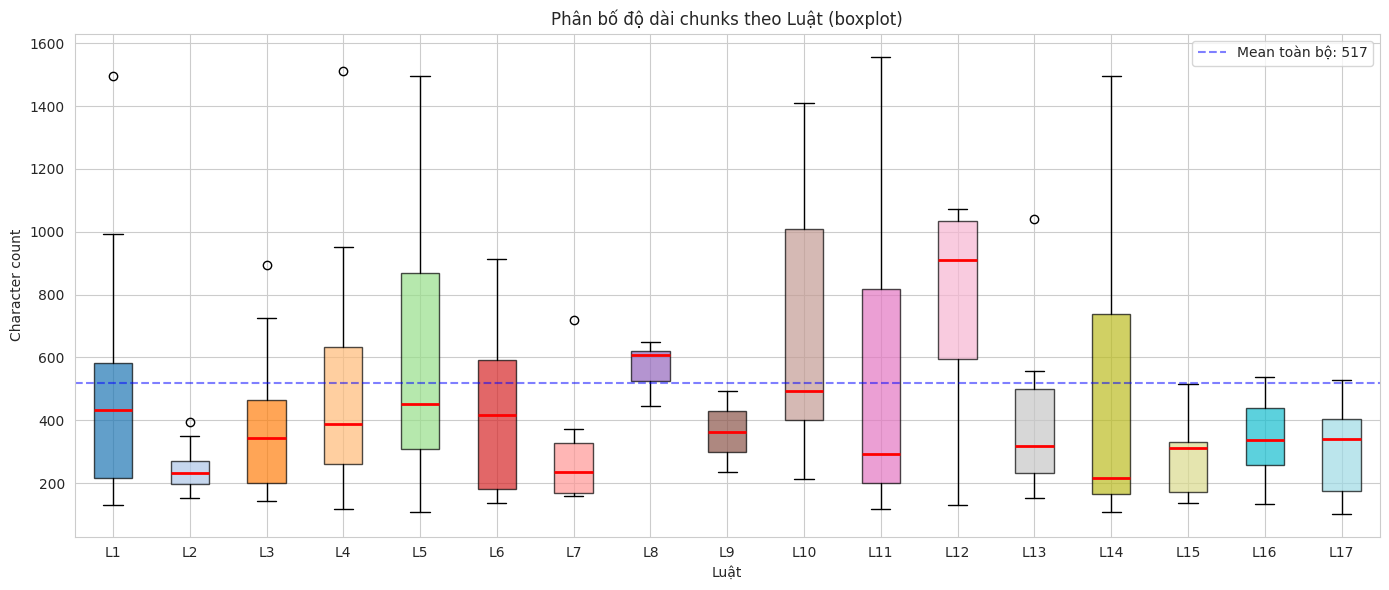

In [15]:
# Boxplot: phân bố độ dài chunks trong mỗi Luật
fig, ax = plt.subplots(figsize=(14, 6))

law_order = sorted(df_law['luat_so'].unique())
box_data = [df_law[df_law['luat_so'] == l]['char_count'].values for l in law_order]
box_labels = [f'L{l}' for l in law_order]

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], plt.cm.tab20(np.linspace(0, 1, len(box_data)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Luật')
ax.set_ylabel('Character count')
ax.set_title('Phân bố độ dài chunks theo Luật (boxplot)')
ax.axhline(y=df['char_count'].mean(), color='blue', linestyle='--', alpha=0.5, label=f'Mean toàn bộ: {df["char_count"].mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Phân tích metadata

Kiểm tra tính nhất quán của metadata.

In [16]:
# Đếm null cho mỗi field
print('📋 SỐ LƯỢNG NULL VALUES THEO TỪNG FIELD:')
null_counts = df.isna().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100).round(1)
null_summary = pd.DataFrame({
    'Null count': null_counts,
    'Null %': null_pct,
    'Non-null count': len(df) - null_counts
})
null_summary[null_summary['Null count'] > 0]

📋 SỐ LƯỢNG NULL VALUES THEO TỪNG FIELD:


,Null count,Null %,Non-null count
special_section,224,78.3,62
dieu_khoan,95,33.2,191
luat_ten,64,22.4,222
luat_so,64,22.4,222
muc_so,25,8.7,261
muc_ten,25,8.7,261


In [17]:
# Kiểm tra chunks không thuộc Luật nào (special sections, phụ lục...)
no_luat = df[df['luat_so'].isna()]
print(f'📋 Chunks KHÔNG thuộc Luật nào: {len(no_luat)}')

if len(no_luat) > 0:
    special_counts = no_luat['special_section'].value_counts(dropna=False)
    print('\nPhân bổ theo special_section:')
    display(special_counts.to_frame('Số chunks'))

📋 Chunks KHÔNG thuộc Luật nào: 64

Phân bổ theo special_section:


,Số chunks
special_section,
Trình tự VAR,31
Hướng dẫn Sin Bins,12
Các sửa đổi chung,4
Các cơ quan quản lý bóng đá,4
Giới thiệu,3
Chương trình chất lượng FIFA,3
NaN,2
Quản lý thay đổi Luật,1
Tương lai,1


In [18]:
# Số mục con trong mỗi Luật
mucs_per_law = df_law.groupby('luat_so').agg(
    num_mucs=('muc_so', 'nunique'),
    num_dieu_khoans=('dieu_khoan', 'nunique')
).reset_index()
mucs_per_law['luat_ten'] = mucs_per_law['luat_so'].map(df_law.set_index('luat_so')['luat_ten'].to_dict())
mucs_per_law = mucs_per_law[['luat_so', 'luat_ten', 'num_mucs', 'num_dieu_khoans']]
print('📋 Số mục/điều khoản mỗi Luật:')
mucs_per_law

📋 Số mục/điều khoản mỗi Luật:


,luat_so,luat_ten,num_mucs,num_dieu_khoans
0,1,SÂN THI ĐẤU,14,8
1,2,BÓNG THI ĐẤU,3,9
2,3,CẦU THỦ,10,24
3,4,TRANG THIẾT BỊ CỦA CẦU THỦ,6,15
4,5,TRỌNG TÀI,7,12
5,6,CÁC QUAN CHỨC TRẬN ĐẤU KHÁC,6,5
6,7,THỜI GIAN TRẬN ĐẤU,5,3
7,8,BẮT ĐẦU VÀ BẮT ĐẦU LẠI TRẬN ĐẤU,2,5
8,9,BÓNG TRONG CUỘC VÀ NGOÀI CUỘC,2,0
9,10,QUYẾT ĐỊNH KẾT QUẢ CỦA TRẬN ĐẤU,4,6


## 8. Phân tích Source Page

Xem chunks rải đều theo trang PDF như thế nào.

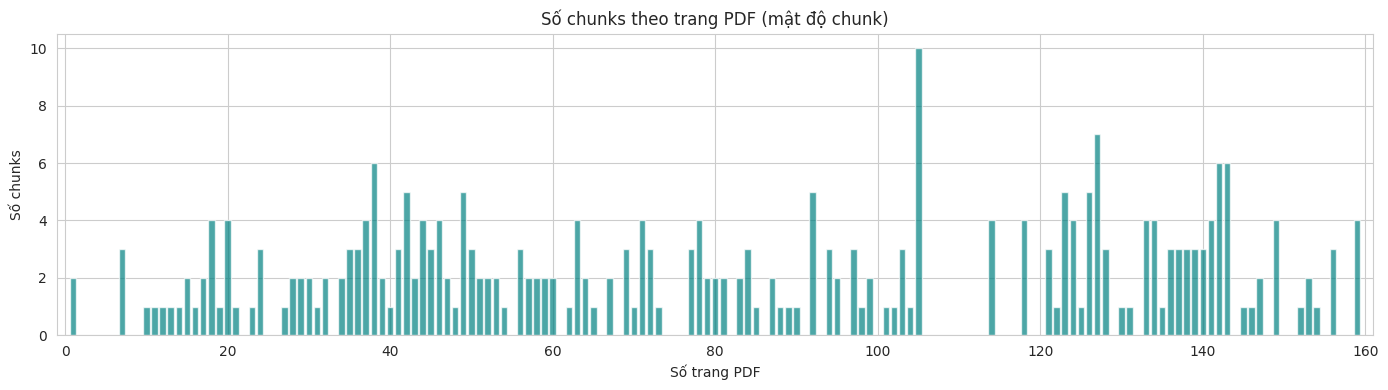


📊 Trang có nhiều chunks nhất:
  Trang 105: 10 chunks — vd: LUẬT 12 - CÁC LỖI VÀ HÀNH VI SAI TRÁI > 3. Các hình thức kỷ ...
  Trang 127: 7 chunks — vd: LUẬT 14 - PHẠT ĐỀN > 1. Trình tự/Thủ tục > 1.5...
  Trang 143: 6 chunks — vd: Trình tự VAR > 1. Các nguyên tắc > 1.12...
  Trang 142: 6 chunks — vd: Trình tự VAR > 1. Các nguyên tắc > 1.6...
  Trang 38: 6 chunks — vd: LUẬT 2 - BÓNG THI ĐẤU > 1. Chất lượng và kích thước > 1.5...
  Trang 42: 5 chunks — vd: LUẬT 3 - CẦU THỦ > 3. Thủ tục thay người > 3.3...
  Trang 49: 5 chunks — vd: LUẬT 4 - TRANG THIẾT BỊ CỦA CẦU THỦ > 1. Sự an toàn > 1.1...
  Trang 92: 5 chunks — vd: LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.1...
  Trang 126: 5 chunks — vd: LUẬT 14 - PHẠT ĐỀN...
  Trang 123: 5 chunks — vd: LUẬT 13 - CÁC QUẢ PHẠT > 2. Trình tự/Thủ tục > 2.2...


In [19]:
# Số chunks mỗi trang
chunks_per_page = df['source_page'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(chunks_per_page.index, chunks_per_page.values, color='teal', alpha=0.7)
ax.set_xlabel('Số trang PDF')
ax.set_ylabel('Số chunks')
ax.set_title('Số chunks theo trang PDF (mật độ chunk)')
ax.set_xlim(chunks_per_page.index.min() - 2, chunks_per_page.index.max() + 2)
plt.tight_layout()
plt.show()

print(f'\n📊 Trang có nhiều chunks nhất:')
top_pages = chunks_per_page.sort_values(ascending=False).head(10)
for page, cnt in top_pages.items():
    sample_breadcrumbs = df[df['source_page'] == page]['breadcrumb'].head(2).tolist()
    print(f'  Trang {page}: {cnt} chunks — vd: {sample_breadcrumbs[0][:60] if sample_breadcrumbs else ""}...')

## 9. Heatmap: Luật × source_page

Trực quan hóa Luật nào nằm ở trang nào của PDF.

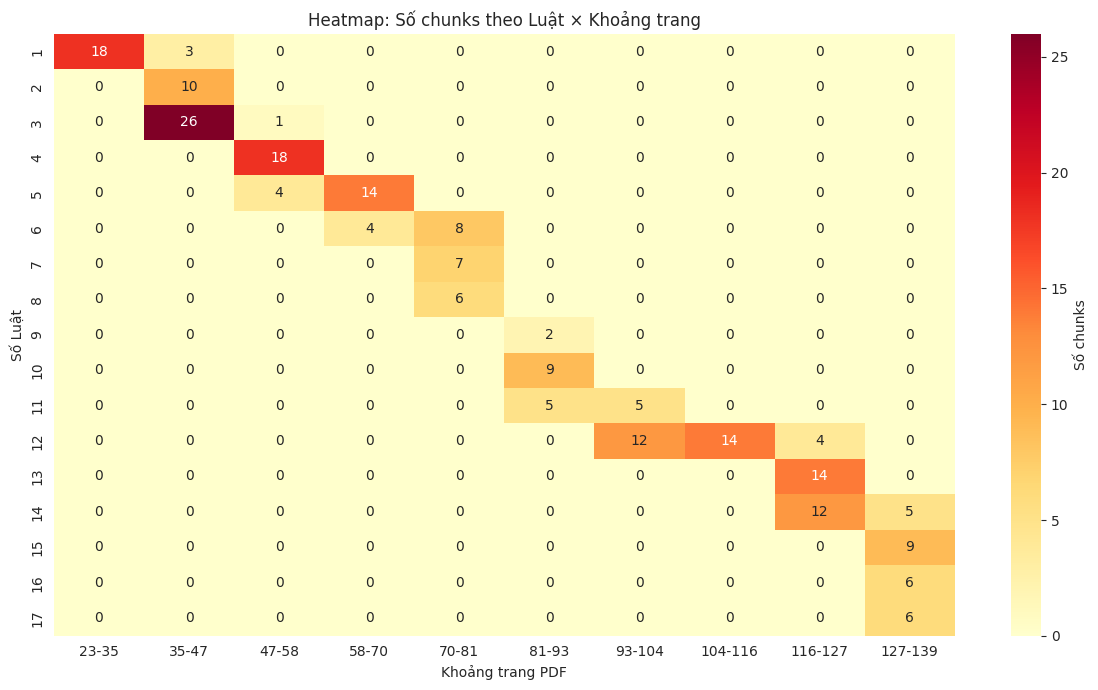

In [20]:
# Pivot table: luat_so × range trang
df_law_copy = df_law.copy()
page_bins = pd.cut(df_law_copy['source_page'], bins=10)
df_law_copy['page_range'] = page_bins.apply(lambda x: f'{int(x.left)}-{int(x.right)}')

heatmap_data = df_law_copy.pivot_table(
    index='luat_so',
    columns='page_range',
    values='chunk_id',
    aggfunc='count',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Số chunks'}, ax=ax)
ax.set_xlabel('Khoảng trang PDF')
ax.set_ylabel('Số Luật')
ax.set_title('Heatmap: Số chunks theo Luật × Khoảng trang')
plt.tight_layout()
plt.show()

## 10. Chunks là bảng (`is_table = true`)

Kiểm tra chunks bảng đã được nhận diện và format đúng chưa.

In [21]:
table_chunks = df[df['is_table'] == True]
print(f'📋 Số chunks là bảng: {len(table_chunks)}')

if len(table_chunks) > 0:
    display(table_chunks[['chunk_id', 'char_count', 'breadcrumb', 'source_page']])
    print('\n--- Nội dung chunk bảng đầu tiên ---')
    print(table_chunks.iloc[0]['text'][:1500])

📋 Số chunks là bảng: 1


,chunk_id,char_count,breadcrumb,source_page
226,L14_M3_p131_BANG_p131,1497,LUẬT 14 - PHẠT ĐỀN > 3. Bảng tóm tắt > Kết quả của đá phạt đền,131



--- Nội dung chunk bảng đầu tiên ---
[LUẬT 14 - PHẠT ĐỀN > 3. Bảng tóm tắt > Kết quả của đá phạt đền]

**Bảng: Kết quả của đá phạt đền**

| Những vi phạm | Bàn thắng | Không bàn thắng |
| --- | --- | --- |
| Cầu thủ đội tấn công xâm lấn khu phạt đền trước khi quả phạt đền được thực hiện | Quả phạt đền được thực hiện lại | Quả phạt gián tiếp |
| Cầu thủ đội phòng ngự xâm lấn khu phạt đền trước khi quả phạt đền được thực hiện | Công nhận bàn thắng | Quả phạt đền được thực hiện lại |
| Cầu thủ cả hai đội xâm lấn khu phạt đền trước khi quả phạt đền được thực hiện | Quả phạt đền được thực hiện lại | Quả phạt đền được thực hiện lại |
| Thủ môn vi phạm | Công nhận bàn thắng | - Không cứu được bóng: quả phạt đền không được thực hiện lại (trừ khi cầu thủ thực hiện quả phạt đền bị ảnh hưởng rõ ràng) - Cứu được bóng: Quả phạt đền được thực hiện lại và nhắc nhở thủ môn, cảnh cáo đối với những lỗi vi phạm tiếp theo |
| Thủ môn và cầu thủ thực hiện quả phạt đền phạm lỗi vào cùng một thời điểm | Quả

## 11. Tìm chunks có vấn đề tiềm ẩn

Các dấu hiệu cần cảnh báo.

In [22]:
issues = []

# 1. Chunks quá ngắn (có thể là rác)
n_short = (df['char_count'] < 100).sum()
issues.append(('Chunks quá ngắn (< 100 ký tự)', n_short))

# 2. Chunks quá dài (vượt context window)
n_long = (df['char_count'] > 1500).sum()
issues.append(('Chunks quá dài (> 1500 ký tự)', n_long))

# 3. Chunks không có Luật và không có special_section
no_context = df[df['luat_so'].isna() & df['special_section'].isna()]
issues.append(('Chunks không thuộc Luật và không có special_section', len(no_context)))

# 4. Chunks có breadcrumb trống hoặc null
no_breadcrumb = df[df['breadcrumb'].isna() | (df['breadcrumb'] == '')]
issues.append(('Chunks không có breadcrumb', len(no_breadcrumb)))

# 5. Trùng chunk_id
duplicate_ids = df['chunk_id'].duplicated().sum()
issues.append(('Chunk_id trùng', duplicate_ids))

# 6. Chunks chỉ có breadcrumb, không có nội dung thực
df['text_without_breadcrumb_len'] = df.apply(
    lambda r: len(r['text'].replace(f"[{r['breadcrumb']}]\n\n", '').strip()) if pd.notna(r['breadcrumb']) else len(r['text']),
    axis=1
)
empty_content = (df['text_without_breadcrumb_len'] < 30).sum()
issues.append(('Chunks gần như rỗng (nội dung < 30 ký tự sau khi bỏ breadcrumb)', empty_content))

print('🔍 KIỂM TRA CÁC VẤN ĐỀ TIỀM ẨN:')
print('=' * 70)
for issue, count in issues:
    icon = '✅' if count == 0 else '⚠️ ' if count < 5 else '🚨'
    print(f'{icon} {issue}: {count}')

df = df.drop('text_without_breadcrumb_len', axis=1)

🔍 KIỂM TRA CÁC VẤN ĐỀ TIỀM ẨN:
⚠️  Chunks quá ngắn (< 100 ký tự): 1
⚠️  Chunks quá dài (> 1500 ký tự): 2
⚠️  Chunks không thuộc Luật và không có special_section: 2
✅ Chunks không có breadcrumb: 0
✅ Chunk_id trùng: 0
✅ Chunks gần như rỗng (nội dung < 30 ký tự sau khi bỏ breadcrumb): 0


In [23]:
# Chunk_id trùng nếu có
if df['chunk_id'].duplicated().any():
    print('🚨 CHUNK_ID TRÙNG:')
    dup_ids = df[df['chunk_id'].duplicated(keep=False)]
    display(dup_ids[['chunk_id', 'breadcrumb', 'source_page', 'char_count']])
else:
    print('✅ Tất cả chunk_id đều unique')

✅ Tất cả chunk_id đều unique


## 12. Word/Token estimation

Ước lượng số token để biết chunks có vừa context của embedding model không.

Quy tắc: tiếng Việt 1 từ ≈ 1.5-2 tokens (model BPE), 1 ký tự ≈ 0.3-0.5 token.

In [24]:
# Ước lượng token theo công thức đơn giản
df['word_count'] = df['text'].str.split().str.len()
df['estimated_tokens'] = (df['char_count'] / 3).round().astype(int)  # rough: 3 chars/token cho VN

print('📊 ƯỚC LƯỢNG WORDS & TOKENS:')
print(f'  Tổng words:                   {df["word_count"].sum():,}')
print(f'  Tổng tokens (estimated):      {df["estimated_tokens"].sum():,}')
print(f'  Words/chunk - mean:           {df["word_count"].mean():.0f}')
print(f'  Words/chunk - max:            {df["word_count"].max()}')
print(f'  Tokens/chunk - mean:          {df["estimated_tokens"].mean():.0f}')
print(f'  Tokens/chunk - max:           {df["estimated_tokens"].max()}')

# Tham chiếu context window
print('\n📚 Tham chiếu context window các embedding model phổ biến:')
models = [
    ('bge-m3', 8192),
    ('text-embedding-3-small', 8191),
    ('text-embedding-004 (Gemini)', 2048),
    ('multilingual-e5-large', 512),
]
for name, ctx in models:
    exceed = (df['estimated_tokens'] > ctx).sum()
    pct = exceed / len(df) * 100
    icon = '✅' if exceed == 0 else '⚠️ ' if pct < 5 else '🚨'
    print(f'  {icon} {name:30s} (max {ctx} tokens): {exceed} chunks vượt ({pct:.1f}%)')

📊 ƯỚC LƯỢNG WORDS & TOKENS:
  Tổng words:                   33,649
  Tổng tokens (estimated):      49,292
  Words/chunk - mean:           118
  Words/chunk - max:            361
  Tokens/chunk - mean:          172
  Tokens/chunk - max:           519

📚 Tham chiếu context window các embedding model phổ biến:
  ✅ bge-m3                         (max 8192 tokens): 0 chunks vượt (0.0%)
  ✅ text-embedding-3-small         (max 8191 tokens): 0 chunks vượt (0.0%)
  ✅ text-embedding-004 (Gemini)    (max 2048 tokens): 0 chunks vượt (0.0%)
  ⚠️  multilingual-e5-large          (max 512 tokens): 1 chunks vượt (0.3%)


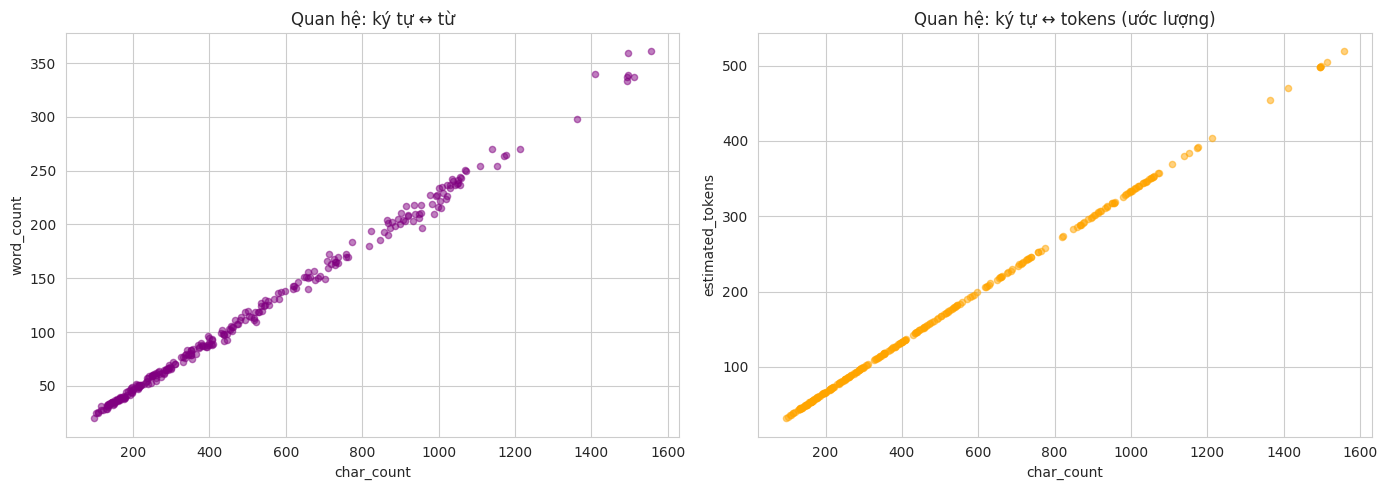

In [25]:
# Scatter: char_count vs estimated_tokens (verify tỷ lệ)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['char_count'], df['word_count'], alpha=0.5, color='purple', s=20)
axes[0].set_xlabel('char_count')
axes[0].set_ylabel('word_count')
axes[0].set_title('Quan hệ: ký tự ↔ từ')

axes[1].scatter(df['char_count'], df['estimated_tokens'], alpha=0.5, color='orange', s=20)
axes[1].set_xlabel('char_count')
axes[1].set_ylabel('estimated_tokens')
axes[1].set_title('Quan hệ: ký tự ↔ tokens (ước lượng)')

plt.tight_layout()
plt.show()

## 13. Explorer: duyệt chunks theo Luật

Đổi `LAW_NO` để xem chunks của Luật cụ thể.

In [26]:
# Đổi số Luật để xem (1-17)
LAW_NO = 11  # ← thay đổi đây

law_chunks = df[df['luat_so'] == LAW_NO].sort_values('chunk_id')

if len(law_chunks) == 0:
    print(f'⚠️  Không có chunks nào của Luật {LAW_NO}')
else:
    law_name = law_chunks.iloc[0]['luat_ten']
    print(f'📖 LUẬT {LAW_NO} - {law_name}')
    print(f'   Số chunks: {len(law_chunks)}')
    print(f'   Tổng ký tự: {law_chunks["char_count"].sum():,}')
    print('=' * 70)
    
    for _, c in law_chunks.iterrows():
        print(f'\n🔹 {c["chunk_id"]} (trang {c["source_page"]}, {c["char_count"]} ký tự)')
        print(f'   {c["breadcrumb"]}')
        print(f'   Preview: {c["text"][:200].replace(chr(10), " ")}...')

📖 LUẬT 11 - VIỆT VỊ
   Số chunks: 10
   Tổng ký tự: 5,205

🔹 L11_M1_DK1.1 (trang 92, 116 ký tự)
   LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.1
   Preview: [LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.1]  1.1. Cầu thủ chỉ ở vị trí việt vị sẽ chưa bị coi là phạm lỗi việt vị....

🔹 L11_M1_DK1.2 (trang 92, 339 ký tự)
   LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.2
   Preview: [LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.2]  1.2. Một cầu thủ ở vị trí việt vị nếu: - Bất cứ phần nào của đầu, thân thể hoặc chân ở trên phần sân của đội đối phương (không bao gồm đường kẻ giữa sân)...

🔹 L11_M1_DK1.3 (trang 92, 240 ký tự)
   LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.3
   Preview: [LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.3]  1.3. Cánh tay và bàn tay của tất cả cầu thủ, bao gồm cả thủ môn, không được xét đến. Ranh giới phía trên của cánh tay thẳng hàng với phía dưới của hốc ná...

🔹 L11_M1_DK1.4 (trang 92, 186 ký tự)
   LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.4
   Preview: [LUẬT 11 - VIỆT VỊ > 1. Vị

## 14. Tìm kiếm chunks theo từ khóa

Search chunks chứa keyword nào đó.

In [27]:
# Thay đổi keyword
KEYWORD = 'việt vị'  # ← thay đổi đây

# Search case-insensitive
matches = df[df['text'].str.contains(KEYWORD, case=False, na=False)]
print(f'🔍 Tìm thấy {len(matches)} chunks chứa "{KEYWORD}"')

if len(matches) > 0:
    for _, c in matches.head(5).iterrows():
        print(f'\n📌 {c["chunk_id"]} - {c["breadcrumb"]}')
        # Highlight keyword bằng cách thêm dấu **
        text_lower = c['text'].lower()
        kw_lower = KEYWORD.lower()
        idx = text_lower.find(kw_lower)
        if idx >= 0:
            start = max(0, idx - 80)
            end = min(len(c['text']), idx + len(KEYWORD) + 80)
            snippet = c['text'][start:end]
            print(f'   ...{snippet}...')

🔍 Tìm thấy 14 chunks chứa "việt vị"

📌 L06_M1_DK1.1 - LUẬT 6 - CÁC QUAN CHỨC TRẬN ĐẤU KHÁC > 1. Các trợ lý trọng tài > 1.1
   ...à đội nào được đá phạt góc, phát bóng hoặc ném biên. - Khi có cầu thủ phạm Luật việt vị. - Khi có thay thế cầu thủ dự bị. - Khi đá phạt đền: xác định thủ môn có di chu...

📌 L11_M1_DK1.1 - LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.1
   ...[LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.1]

1.1. Cầu thủ chỉ ở vị trí việt vị sẽ chưa bị coi là...

📌 L11_M1_DK1.2 - LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.2
   ...[LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.2]

1.2. Một cầu thủ ở vị trí việt vị nếu: - Bất cứ phầ...

📌 L11_M1_DK1.3 - LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.3
   ...[LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.3]

1.3. Cánh tay và bàn tay của tất cả cầu thủ, bao gồ...

📌 L11_M1_DK1.4 - LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.4
   ...[LUẬT 11 - VIỆT VỊ > 1. Vị trí việt vị > 1.4]

1.4. Một cầu thủ không ở vị trí việt vị nếu ngang h...


## 15. Xuất báo cáo tóm tắt

Tổng hợp các metric quan trọng để báo cáo / lưu trữ.

In [28]:
report = {
    'tong_chunks': int(len(df)),
    'tong_ky_tu': int(df['char_count'].sum()),
    'tong_tu': int(df['word_count'].sum()),
    'tong_token_uoc_luong': int(df['estimated_tokens'].sum()),
    'char_count_stats': {
        'min': int(df['char_count'].min()),
        'mean': round(float(df['char_count'].mean()), 1),
        'median': float(df['char_count'].median()),
        'max': int(df['char_count'].max()),
        'std': round(float(df['char_count'].std()), 1),
        'p95': float(df['char_count'].quantile(0.95)),
        'p99': float(df['char_count'].quantile(0.99)),
    },
    'phan_bo_section_type': df['section_type'].value_counts().to_dict(),
    'so_luat': int(df['luat_so'].nunique()),
    'so_trang_pdf_su_dung': int(df['source_page'].nunique()),
    'so_chunks_la_bang': int(df['is_table'].sum()),
    'canh_bao': {
        'chunks_qua_ngan_<100': int((df['char_count'] < 100).sum()),
        'chunks_qua_dai_>1500': int((df['char_count'] > 1500).sum()),
        'chunks_qua_dai_>2000': int((df['char_count'] > 2000).sum()),
        'chunks_id_trung': int(df['chunk_id'].duplicated().sum()),
    }
}

print(json.dumps(report, ensure_ascii=False, indent=2))

# Lưu ra file
OUT_PATH = 'chunks_analysis_report.json'
with open(OUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)
print(f'\n💾 Báo cáo đã lưu: {OUT_PATH}')

{
  "tong_chunks": 286,
  "tong_ky_tu": 147856,
  "tong_tu": 33649,
  "tong_token_uoc_luong": 49292,
  "char_count_stats": {
    "min": 97,
    "mean": 517.0,
    "median": 407.5,
    "max": 1557,
    "std": 344.7,
    "p95": 1072.25,
    "p99": 1495.3
  },
  "phan_bo_section_type": {
    "luat": 221,
    "phu_luc": 51,
    "huong_dan": 13,
    "bang": 1
  },
  "so_luat": 17,
  "so_trang_pdf_su_dung": 113,
  "so_chunks_la_bang": 1,
  "canh_bao": {
    "chunks_qua_ngan_<100": 1,
    "chunks_qua_dai_>1500": 2,
    "chunks_qua_dai_>2000": 0,
    "chunks_id_trung": 0
  }
}

💾 Báo cáo đã lưu: chunks_analysis_report.json


## 🎯 Kết luận

Notebook này cung cấp **15 góc nhìn** vào file chunks:

1. **Setup & Load** — đọc dữ liệu
2. **Tổng quan nhanh** — numbers cốt lõi
3. **Phân bố character count** — histogram, boxplot, buckets
4. **Outliers** — quá ngắn / quá dài
5. **section_type** — pie chart, bar chart
6. **Phân bố theo Luật** — bar chart + boxplot
7. **Metadata consistency** — null counts, mục/điều khoản
8. **source_page** — mật độ chunks theo trang
9. **Heatmap** — Luật × trang
10. **is_table chunks** — kiểm tra bảng
11. **Vấn đề tiềm ẩn** — 6 dấu hiệu cảnh báo
12. **Token estimation** — vừa context window không?
13. **Explorer theo Luật** — duyệt nội dung
14. **Search keyword** — tìm từ khóa
15. **Báo cáo tóm tắt** — export JSON

**Bước tiếp theo**: nếu mọi chỉ số đều OK → tiến hành embedding chunks và lưu vào Vector DB.